In [1]:
import matplotlib.pyplot as plt
import cv2
import scienceplots

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
from typing import Dict
from typing import Callable


In [2]:
from boulder_statistics.inspect_tools import QMAPInspector


qm = QMAPInspector()


qm.agg_db.filter(pl.col("number_of_samples") > 1e3)

boulder_id,Gamma,Area,center_x,min_x,max_x,center_y,min_y,max_y,center_z,min_z,max_z,number_of_samples
u32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,u32
6958,3.219428,37.05526,-0.18899,-0.191686,-0.185285,0.112289,0.109349,0.116093,-0.099497,-0.102299,-0.09622,19712
3,1.907463,12.501315,0.10504,0.102105,0.107723,-0.148312,-0.149251,-0.146984,-0.14665,-0.147885,-0.14513,13568
5377,1.985888,12.2261,-0.020925,-0.022922,-0.018774,0.209454,0.208265,0.210081,0.123844,0.122224,0.125376,5120
3674,1.910504,9.162981,-0.06798,-0.069572,-0.066363,0.120124,0.118448,0.121519,-0.182608,-0.183961,-0.181247,5376
7086,4.667024,42.233845,-0.207865,-0.209605,-0.205139,-0.040292,-0.044482,-0.03567,0.111929,0.109563,0.113927,15872
…,…,…,…,…,…,…,…,…,…,…,…,…
3888874,3.067629,0.955257,0.137342,0.136864,0.137775,-0.14119,-0.142002,-0.140573,0.134157,0.133819,0.134628,1232
3889949,2.444949,0.875788,0.131569,0.131073,0.132099,0.130527,0.130079,0.13092,0.128816,0.128411,0.129202,1408
3888794,3.234682,1.371209,0.132184,0.131416,0.132887,-0.149689,-0.150178,-0.149223,0.131621,0.131138,0.132065,1594


In [3]:
qm.full_db.filter(pl.col("i") == 1).collect()

i,j,face,area,detailed_survey band depth 350,detailed_survey band depth 440,detailed_survey slope 1000,detailed_survey ratio 1000,detailed_survey sigma band depth 350,detailed_survey sigma band depth 440,detailed_survey sigma slope 1000,detailed_survey sigma ratio 1000,recona band depth 350,recona band depth 440,recona slope 1000,recona ratio 1000,recona sigma band depth 350,recona sigma band depth 440,recona sigma slope 1000,recona sigma ratio 1000,reconb band depth 350,reconb band depth 440,reconb slope 1000,reconb ratio 1000,reconb sigma band depth 350,reconb sigma band depth 440,reconb sigma slope 1000,reconb sigma ratio 1000,detailed_survey band depth,detailed_survey reflectance,detailed_survey slope1 poly,detailed_survey slope2 poly,detailed_survey sigma band depth,detailed_survey sigma reflectance,detailed_survey sigma slope1 poly,detailed_survey sigma slope2 poly,recona band depth,recona reflectance,recona slope1 poly,recona slope2 poly,recona sigma band depth,recona sigma reflectance,recona sigma slope1 poly,recona sigma slope2 poly,reconc band depth,reconc reflectance,reconc slope1 poly,reconc slope2 poly,reconc sigma band depth,reconc sigma reflectance,reconc sigma slope1 poly,reconc sigma slope2 poly,uint8_reflectance,32bit_reflectance,positions_x,positions_y,positions_z,detection_lod_level,detection_lod_code,boulder_id
u32,u32,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,u8,f32,f32,f32,f32,u8,str,u32
1,0,"""negx""",0.000676,1.002986,1.010986,1.001857,NaN,0.001074,0.00058,0.000591,NaN,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,null,null,null,null,null,null,null,null,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64,0.011107,0.138693,0.13874,-0.138707,null,null,null
1,1,"""negx""",0.000681,1.002986,1.010986,1.001857,NaN,0.001074,0.00058,0.000591,NaN,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,null,null,null,null,null,null,null,null,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59,0.010167,0.138667,0.138749,-0.138711,null,null,null
1,2,"""negx""",0.000654,1.002986,1.010986,1.001857,NaN,0.001074,0.00058,0.000591,NaN,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,null,null,null,null,null,null,null,null,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,67,0.011566,0.138643,0.138756,-0.138716,null,null,null
1,3,"""negx""",0.000647,1.002986,1.010986,1.001857,NaN,0.001074,0.00058,0.000591,NaN,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,null,null,null,null,null,null,null,null,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74,0.012794,0.138617,0.138762,-0.138724,null,null,null
1,4,"""negx""",0.000632,1.002986,1.010986,1.001857,NaN,0.001074,0.00058,0.000591,NaN,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,null,null,null,null,null,null,null,null,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70,0.012029,0.138591,0.138768,-0.138733,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1,8187,"""posz""",0.000642,1.002942,1.013387,0.999009,NaN,0.002091,0.001041,0.001174,NaN,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,-9999.0,-9999.0,NaN,-9999.0,0.145376,0.039529,0.008644,0.003922,0.011831,0.000182,0.000079,0.00003,null,null,null,null,null,null,null,null,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,146,0.025234,-0.135213,-0.135087,-0.135204,null,null,null
1,8188,"""posz""",0.000639,1.002942,1.013387,0.999009,NaN,0.002091,0.001041,0.001174,NaN,-9999.0,-9999.0,Na

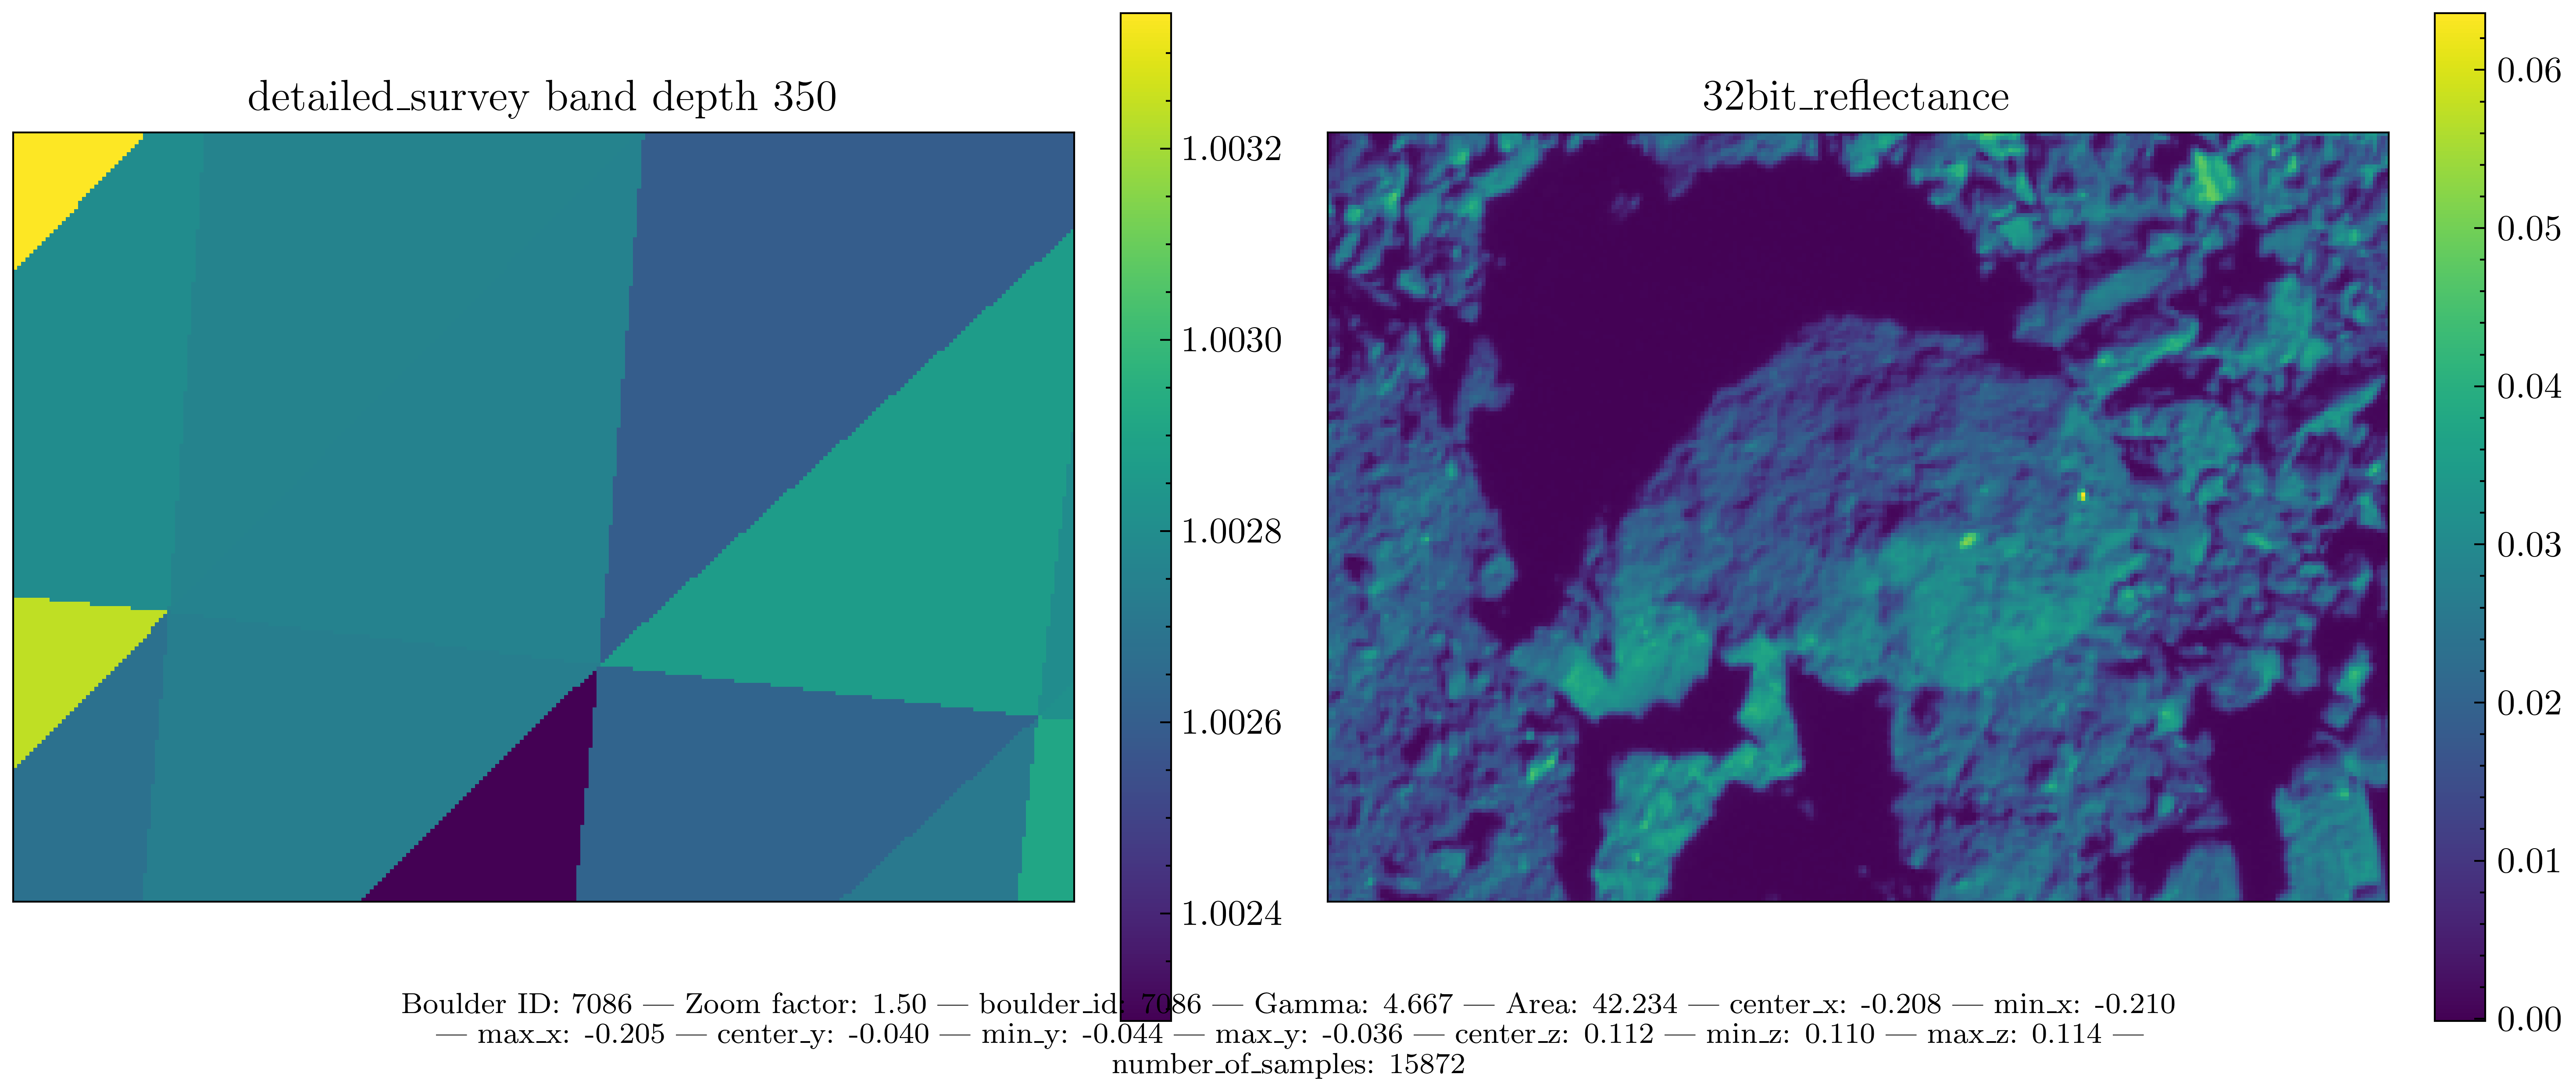

In [4]:
qm.render_multi_plot(7086, "detailed_survey band depth 350")